In [1]:
import os
import copy
import itertools
import numpy as np
import scipy
from scipy import optimize
import pandas
import matplotlib.pyplot as plt
from IPython.display import Image
import sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, FunctionTransformer, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier

# Implementing decision trees

We will implement a simple decision tree regressor, with unidimensional inputs and outputs. The inputs are assumed to be numerical.

The goal is to understand how it works, and to test it on a simple regression task (regression of a function of one variable).

**Question 1**

Fill the blanks in the class below. This class implements a tree structure and will be used to perform a regression.

In [2]:
class Node():
    def __init__(self, X, y):
        self.n = X.shape[0]     # number of samples
        self.X = X              # inputs
        self.y = y              # targets
        self.mean = y.mean()    # mean of the targets, used to estimate them
        
        # loss: sum of squared distances between the y_i and the mean
        self.loss = np.sum((y - self.mean)**2)

        self.pivot = None       # pivot: value to which we compare the X_i in order to split the data in two
        self.child_lt = None    # child containing the X_i which are less than (lt) the pivot
        self.child_gt = None    # child containing the X_i which are greater than (gt) the pivot
        
        self.is_leaf = True     # True by default, False if the node has children
        
    def predict(self, X):
        """
        Given an input X, estimate the target y.
        """
        # if this node is leaf, estimate the y_i with self.mean
        if self.is_leaf:
            return np.ones(X.shape) * self.mean

        # otherwise, estimate the y_i with its children
        y = np.empty(X.shape)
        
        is_lt = (X <= self.pivot)
        y[is_lt] = self.child_lt.predict(X[is_lt])
        
        is_gt = np.logical_not(is_lt)
        y[is_gt] = self.child_gt.predict(X[is_gt])
        
        return y
    
    def loop(self):
        """
        Loop over the leaves of the tree rooted in the current node.
        """
        if self.is_leaf:
            # if the current node is leaf, return it
            yield self
        else:
            # otherwise, loop over its children
            yield from self.child_lt.loop()
            yield from self.child_gt.loop()
        
    def compute_pivot(self):
        """
        Computes the optimal pivot for the current node. A pivot should split the data in two, 
        each of them being estimated by its own mean. The optimal pivot should minimize the loss 
        after the split.

        Returns the pivot and the loss decrease (loss after the split - loss before the split).
        """
        # define the function to minimize
        def f(pivot):
            is_lt = (self.X <= pivot)
            ylt = self.y[is_lt]
            loss_lt = np.sum((ylt - ylt.mean())**2)
            
            is_gt = np.logical_not(is_lt)
            ygt = self.y[is_gt]
            loss_gt = np.sum((ygt - ygt.mean())**2)
            
            return loss_lt + loss_gt

        # use scipy to minimize f
        res = optimize.minimize_scalar(f, bracket = (self.X.min(), self.X.max()))

        # return the pivot and the loss decrease
        return {"pivot": res["x"], "loss": res["fun"] - self.loss}
    
    def build_children(self, pivot):
        """
        Given a pivot, build children for the current node
        """
        is_lt = (self.X <= pivot)
        self.child_lt = Node(self.X[is_lt], self.y[is_lt])
        
        is_gt = np.logical_not(is_lt)
        self.child_gt = Node(self.X[is_gt], self.y[is_gt])
        
        self.pivot = pivot
        
        self.is_leaf = False
        
    def add_node(self):
        """
        1. loop over the leaves of the tree rooted in the current node,
        2. compute the best pivot and the associated loss decrease for each of the leaves,
        3. select the leaf with the best loss decrease,
        4. build children for this leaf, with the optimal pivot that has been computed.
        """
        # initialize the search
        best_loss = np.inf
        best_node = None
        best_dct = None

        # search the best node and store the best pivot
        for node in self.loop():
            if node.is_leaf:
                dct = node.compute_pivot()
                if dct["loss"] < best_loss:
                    best_loss = dct["loss"]
                    best_dct = dct
                    best_node = node

        # build children for the best node
        best_node.build_children(best_dct["pivot"])

    def build_tree(self, n_leaves):
        """
        Construct an entire regression tree with n_leaves leaves.
        """
        # n_leaves: number of leaves after training (must be > 1)
        if n_leaves <= 1:
            raise ValueError(f"n_leaves must be > 1, got {n_leaves}")
        
        for i in range(n_leaves - 1):
            self.add_node()

**Question 2**

Perform a regression on a dataset that is built with the sine function, without noise.

Plot the sine and the decision tree regressor with various numbers of leaves.

In [3]:
X = np.linspace(-10, 10, 100)
y = np.sin(X)

/tmp/ipykernel_35319/1701656326.py:64: RuntimeWarning: Mean of empty slice
  loss_gt = np.sum((ygt - ygt.mean())**2)
/home/pwolinski/envs/pytorch/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_35319/1701656326.py:60: RuntimeWarning: Mean of empty slice
  loss_lt = np.sum((ylt - ylt.mean())**2)


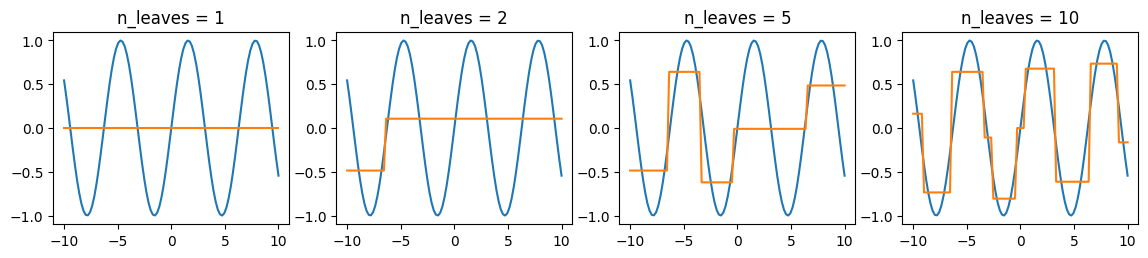

In [4]:
lst_plots = [2, 5, 10]
n = len(lst_plots) + 1

root = Node(X, y)

plt.rcParams["figure.figsize"] = (14, 2.5)
fig, ax = plt.subplots(1, n)

ax[0].plot(X, y)
ax[0].plot(X, root.predict(X))
ax[0].set_title(f"n_leaves = 1")
idx = 1

for i in range(2, 11):
    root.add_node()
    if i in lst_plots:
        ax[idx].plot(X, y)
        ax[idx].plot(X, root.predict(X))
        ax[idx].set_title(f"n_leaves = {i}")
        idx += 1

**Question 3**

Add some aberrant values to the dataset and perform tree regression with a larger number of leaves.

What do we observe?

In [5]:
y = np.sin(X)

y[20] = 4
y[40] = -4
y[60] = 4

/tmp/ipykernel_35319/1701656326.py:64: RuntimeWarning: Mean of empty slice
  loss_gt = np.sum((ygt - ygt.mean())**2)
/tmp/ipykernel_35319/1701656326.py:60: RuntimeWarning: Mean of empty slice
  loss_lt = np.sum((ylt - ylt.mean())**2)


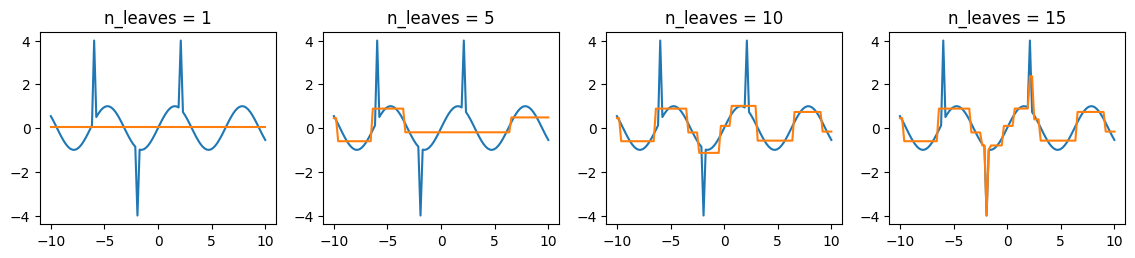

In [6]:
lst_plots = [5, 10, 15]
n = len(lst_plots) + 1

root = Node(X, y)

plt.rcParams["figure.figsize"] = (14, 2.5)
fig, ax = plt.subplots(1, n)

ax[0].plot(X, y)
ax[0].plot(X, root.predict(X))
ax[0].set_title(f"n_leaves = 1")
idx = 1

for i in range(2, 16):
    root.add_node()
    if i in lst_plots:
        ax[idx].plot(X, y)
        ax[idx].plot(X, root.predict(X))
        ax[idx].set_title(f"n_leaves = {i}")
        idx += 1

**Answer**

We observe an overfit of the dataset: outliers are fitted as well as the ordinary points.

# Iris classification

We will use `sklearn.tree.DecisionTreeClassifier` to classify the Iris dataset

In [7]:
from sklearn.datasets import load_iris

iris_data = load_iris()
X = iris_data["data"]
y = iris_data["target"]
n = X.shape[0]

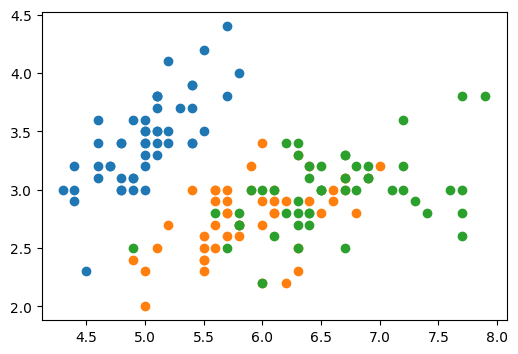

In [8]:
plt.rcParams["figure.figsize"] = (6, 4)
for cl in [0, 1, 2]:
    select = (y == cl)
    plt.scatter(X[select,0], X[select,1], label = f"Class {cl}")

**Question**

Perform decision tree classification on the Iris dataset. Compute the cross-validation score and plot the decision graph by using `sklearn.tree.plot_tree` and `plt.show()`.

Try to modify some arguments and visualize the result:
* `max_leaf_nodes`;
* `max_depth`.

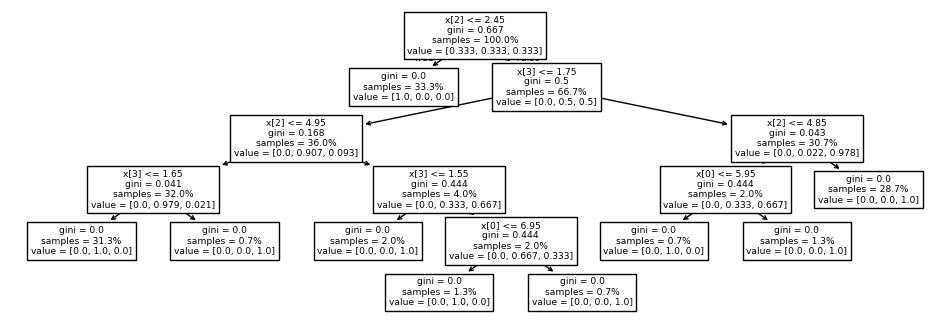

In [9]:
# Default parameters

clf = DecisionTreeClassifier()
clf.fit(X, y)

plt.rcParams["figure.figsize"] = (12, 4)
sklearn.tree.plot_tree(clf, proportion = True)
plt.show()

In [10]:
sum(cross_val_score(clf, X, y)) / 5

np.float64(0.9600000000000002)

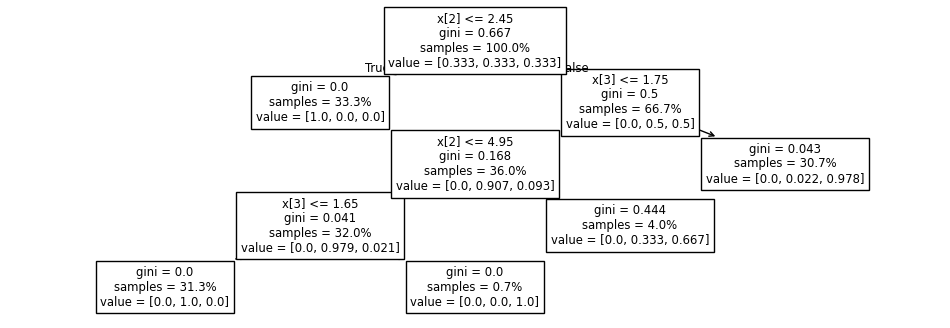

In [11]:
# max_leaf_nodes = 5

clf = DecisionTreeClassifier(max_leaf_nodes = 5)
clf.fit(X, y)

plt.rcParams["figure.figsize"] = (12, 4)
sklearn.tree.plot_tree(clf, proportion = True)
plt.show()

In [12]:
sum(cross_val_score(clf, X, y)) / 5

np.float64(0.9533333333333334)

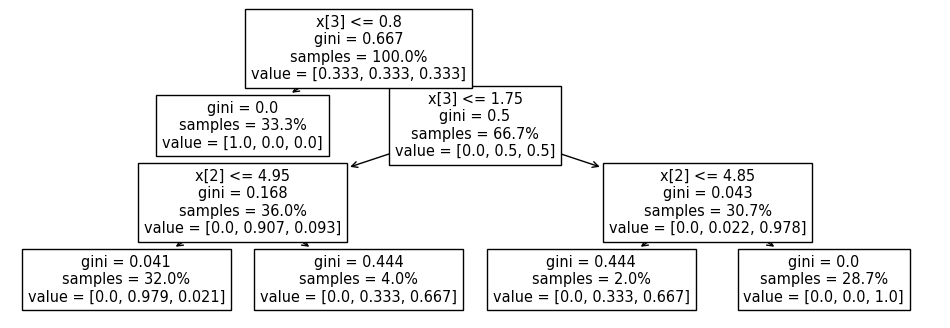

In [13]:
# max_depth = 3

clf = DecisionTreeClassifier(max_depth = 3)
clf.fit(X, y)

plt.rcParams["figure.figsize"] = (12, 4)
sklearn.tree.plot_tree(clf, proportion = True)
plt.show()

In [14]:
sum(cross_val_score(clf, X, y)) / 5

np.float64(0.9733333333333334)

# Decision trees regression in sport

The goal is to predict the salary of baseball players depending of several features.

In [15]:
df = pandas.read_csv("Hitters.csv")
df

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,N,E,325,9,3,700.0,N
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,A,E,313,381,20,875.0,A
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,A,W,37,113,7,385.0,A
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,A,E,1314,131,12,960.0,A


**Question 1**

Remove data points with a non-numerical salary.

In [16]:
df = df.dropna(subset = ["Salary"])

**Question 2**

Plot the histogram of the salaries. What do we observe? Is it reasonable to perform regression on it? What kind of preprocessing should we do?

(array([108.,  50.,  49.,  27.,  11.,   7.,   2.,   6.,   1.,   2.]),
 array([  67.5 ,  306.75,  546.  ,  785.25, 1024.5 , 1263.75, 1503.  ,
        1742.25, 1981.5 , 2220.75, 2460.  ]),
 <BarContainer object of 10 artists>)

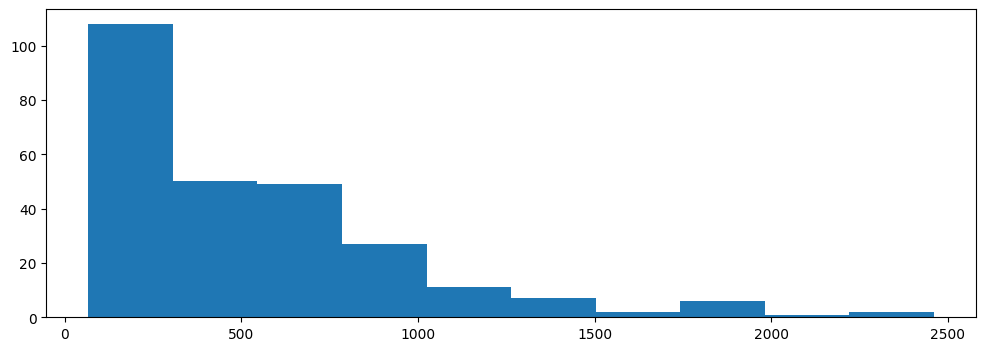

In [17]:
y = df["Salary"]
plt.hist(y)

**Answer**

The salaries span several orders of magnitude and there are significantly more salaries close to 0 than far from it. We should probably take the log to have a more evenly distributed variable.

**Question 3**

Perform regression with decision trees. Plot the final tree.

One can pre-process categorical data with the `OrdinalEncoder` transform.

In [18]:
X = df.drop(columns = ["Salary"])
y = df["Salary"]

In [19]:
labels_categ = ["League", "Division", "NewLeague"]
labels_numeric = [lab for lab in X.columns if lab not in labels_categ]

preprocess = ColumnTransformer([("le", OrdinalEncoder(), labels_categ),
                                ("identity", FunctionTransformer(), labels_numeric)])

In [20]:
reg = DecisionTreeRegressor()

pipeline = Pipeline([("preprocess", preprocess), ("reg", reg)])
pipeline.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('le', ...), ('identity', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

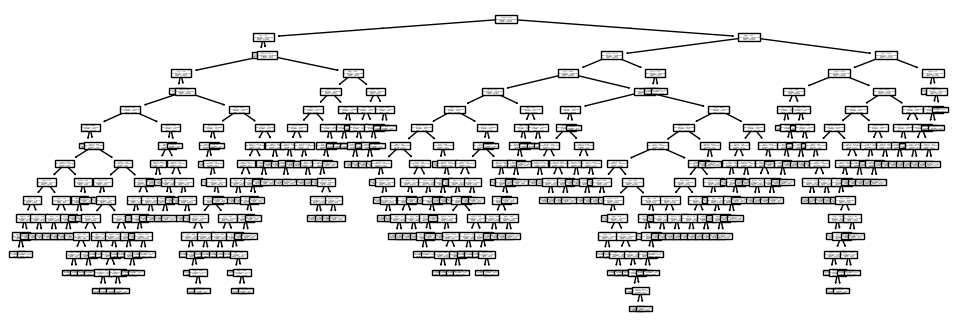

In [21]:
plt.rcParams["figure.figsize"] = (12, 4)
sklearn.tree.plot_tree(reg, proportion = True)
plt.show()

**Question 4**

Split the dataset into a training set and a test set.

Compute the train mean squared error (MSE) and the test MSE. What do we observe?

By using cross-validation, find the best regularization parameter `ccp_alpha` of the decision tree. Plot the selected tree.

**Note:** the selected tree may vary much with the train/test split.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2)

In [23]:
reg = DecisionTreeRegressor()
pipeline = Pipeline([("preprocess", preprocess), ("reg", reg)])
pipeline.fit(X_train, y_train)

train_score = np.mean(((pipeline.predict(X_train) - y_train)**2).to_numpy())
test_score = np.mean(((pipeline.predict(X_test) - y_test)**2).to_numpy())

print(f"Train loss: {train_score}")
print(f"Test loss: {test_score}")

Train loss: 0.0
Test loss: 108163.64005243397


**Answer**

We observe overfitting: the train loss is 0, while the test loss is greater than 0.

In [24]:
from sklearn.model_selection import GridSearchCV

n_splits = 10

param_grid = {"reg__ccp_alpha": np.linspace(0, 1, 11)}
grid_search = GridSearchCV(estimator = pipeline, param_grid = param_grid, cv = n_splits, n_jobs = -1, scoring = "neg_mean_squared_error")

In [25]:
grid_search.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'reg__ccp_alpha': array([0. , 0....8, 0.9, 1. ])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also dis

In [26]:
best_model = grid_search.best_estimator_

ccp_alpha = best_model["reg"].ccp_alpha

best_model.fit(X_train, y_train)

train_score = ((best_model.predict(X_train) - y_train)**2).mean()
test_score = ((best_model.predict(X_test) - y_test)**2).mean()

print(f"alpha_ccp = {ccp_alpha}")
print(f"Train score: {train_score}")
print(f"Test score: {test_score}")

alpha_ccp = 0.9
Train score: 8.932861652645508
Test score: 81120.22914576286


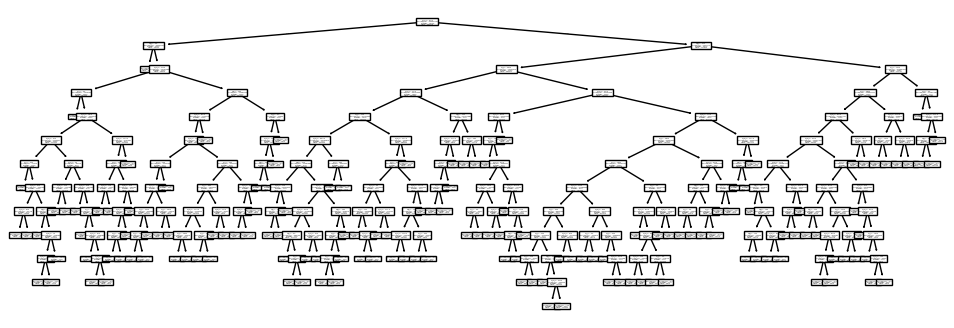

In [27]:
plt.rcParams["figure.figsize"] = (12, 4)
sklearn.tree.plot_tree(best_model["reg"], proportion = True)
plt.show()